In [11]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model= "llama-3.1-8b-instant")

In [4]:
def call_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {'messages': [response]}

In [6]:
builder = StateGraph(MessagesState)

builder.add_node("call_node", call_node)

builder.add_edge(START, 'call_node')
builder.add_edge('call_node', END)

graph = builder.compile()

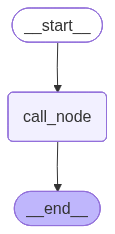

In [7]:
graph

In [9]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Aryan."}]})

{'messages': [HumanMessage(content='Hi! My name is Aryan.', additional_kwargs={}, response_metadata={}, id='16ed7385-fb2a-4881-9b23-298156352d37'),
  AIMessage(content="Hello Aryan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 43, 'total_tokens': 70, 'completion_time': 0.053557748, 'completion_tokens_details': None, 'prompt_time': 0.002133046, 'prompt_tokens_details': None, 'queue_time': 0.049723129, 'total_time': 0.055690794}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6488-309f-74c1-aac5-b55eb7752685-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 27, 'total_tokens': 70})]}

In [10]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='70eedc69-3311-42ed-a0e5-68708f6f434a'),
  AIMessage(content="I don't have any information about your name. I'm a large language model, I don't have the ability to know or remember personal information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I'd be happy to chat with you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 40, 'total_tokens': 117, 'completion_time': 0.79543649, 'completion_tokens_details': None, 'prompt_time': 0.002199526, 'prompt_tokens_details': None, 'queue_time': 0.054792253, 'total_time': 0.797636016}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'

In [12]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer= checkpointer)

In [13]:
config1 = {'configurable': {'thread_id': 'thread-1'}}
config2 = {'configurable': {'thread_id': 'thread-2'}}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Aryan."}]}, config1)

{'messages': [HumanMessage(content='Hi! My name is Aryan.', additional_kwargs={}, response_metadata={}, id='5538accb-7b07-43aa-b59d-e820bb4d3445'),
  AIMessage(content='Nice to meet you, Aryan. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 43, 'total_tokens': 67, 'completion_time': 0.025297644, 'completion_tokens_details': None, 'prompt_time': 0.003027079, 'prompt_tokens_details': None, 'queue_time': 0.058501284, 'total_time': 0.028324723}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e648b-00f1-7563-969b-cc0a86750fa3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 24, 'total_tokens': 67})]}

In [15]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config1)

{'messages': [HumanMessage(content='Hi! My name is Aryan.', additional_kwargs={}, response_metadata={}, id='5538accb-7b07-43aa-b59d-e820bb4d3445'),
  AIMessage(content='Nice to meet you, Aryan. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 43, 'total_tokens': 67, 'completion_time': 0.025297644, 'completion_tokens_details': None, 'prompt_time': 0.003027079, 'prompt_tokens_details': None, 'queue_time': 0.058501284, 'total_time': 0.028324723}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e648b-00f1-7563-969b-cc0a86750fa3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 24, 'total_tokens': 67}),
  HumanMessage(content='What is my name', additional_kwargs={}, response_metadata={}, id

In [18]:
vals = graph.get_state(config1).values

In [19]:
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Aryan.
- AIMessage : Nice to meet you, Aryan. Is there something I can help you with or would you like to chat?
- HumanMessage : What is my name
- AIMessage : Your name is Aryan.
